In [11]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split , GridSearchCV , cross_val_score
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [5]:
df = pd.read_excel('churn_prediction_data.xlsx',sheet_name=0)

In [159]:
test_df = pd.read_excel('churn_prediction_data.xlsx',sheet_name=1)

In [7]:
df.shape

(6007, 32)

In [9]:
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11098-MAD,Female,30,Yes,Madhya Pradesh,0,31,Deal 1,Yes,No,Yes,Fiber Optic,Yes,Yes,No,Yes,No,Yes,Yes,Yes,Two Year,No,Bank Withdrawal,95.099998,6683.399902,0.00,0,631.719971,7315.120117,Stayed,Other,Other
1,11114-PUN,Male,51,No,Punjab,5,9,Deal 5,Yes,No,Yes,DSL,No,No,Yes,No,No,No,No,No,Month-to-Month,Yes,Bank Withdrawal,49.150002,169.050003,0.00,10,122.370003,301.420013,Churned,Competitor,Competitor had better devices
2,11167-WES,Female,43,Yes,West Bengal,3,28,Deal 1,Yes,Yes,Yes,Fiber Optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Two Year,Yes,Bank Withdrawal,116.050003,8297.500000,42.57,110,1872.979980,10237.910156,Stayed,Other,Other
3,11179-MAH,Male,35,No,Maharashtra,10,12,NaN,Yes,No,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Credit Card,84.400002,5969.299805,0.00,0,219.389999,6188.689941,Stayed,Other,Other
4,11180-TAM,Male,75,Yes,Tamil Nadu,12,27,Deal 2,Yes,No,Yes,DSL,Yes,No,No,Yes,Yes,Yes,No,No,Two Year,Yes,Credit Card,72.599998,4084.350098,0.00,140,332.079987,4556.430176,Stayed,Other,Other


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6007 non-null   object 
 1   Gender                       6007 non-null   object 
 2   Age                          6007 non-null   int64  
 3   Married                      6007 non-null   object 
 4   State                        6007 non-null   object 
 5   Number_of_Referrals          6007 non-null   int64  
 6   Tenure_in_Months             6007 non-null   int64  
 7   Value_Deal                   2710 non-null   object 
 8   Phone_Service                6007 non-null   object 
 9   Multiple_Lines               6007 non-null   object 
 10  Internet_Service             6007 non-null   object 
 11  Internet_Type                4784 non-null   object 
 12  Online_Security              6007 non-null   object 
 13  Online_Backup     

In [10]:
df.isna().sum()

Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3297
Phone_Service                     0
Multiple_Lines                    0
Internet_Service                  0
Internet_Type                  1223
Online_Security                   0
Online_Backup                     0
Device_Protection_Plan            0
Premium_Support                   0
Streaming_TV                      0
Streaming_Movies                  0
Streaming_Music                   0
Unlimited_Data                    0
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [26]:
df.duplicated().sum()


np.int64(0)

In [14]:
cat_df = df.select_dtypes(include='object').drop(columns=['Customer_ID','Churn_Category', 'Churn_Reason'])
num_df = df.select_dtypes(include='number')

In [16]:
for col in cat_df.columns:
    print(df[col].value_counts())

Gender
Female    3779
Male      2228
Name: count, dtype: int64
Married
No     3012
Yes    2995
Name: count, dtype: int64
State
Uttar Pradesh      581
Tamil Nadu         561
Maharashtra        463
Karnataka          439
Haryana            371
Andhra Pradesh     370
West Bengal        345
Punjab             322
Gujarat            315
Jammu & Kashmir    313
Bihar              308
Madhya Pradesh     270
Telangana          260
Rajasthan          246
Kerala             194
Odisha             143
Assam              129
Delhi              119
Jharkhand          105
Uttarakhand         60
Chhattisgarh        55
Puducherry          38
Name: count, dtype: int64
Value_Deal
Deal 2    758
Deal 5    578
Deal 4    540
Deal 1    469
Deal 3    365
Name: count, dtype: int64
Phone_Service
Yes    5417
No      590
Name: count, dtype: int64
Multiple_Lines
No     3335
Yes    2672
Name: count, dtype: int64
Internet_Service
Yes    4784
No     1223
Name: count, dtype: int64
Internet_Type
Fiber Optic    2675
DSL 

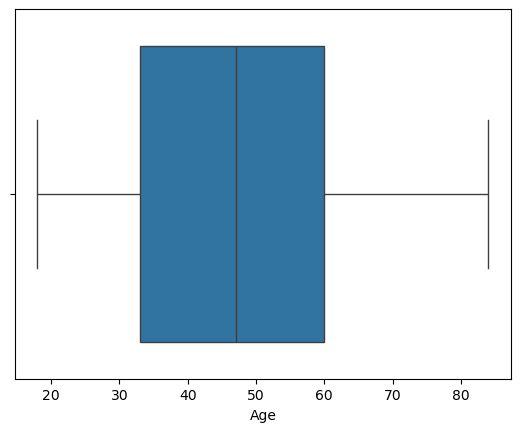

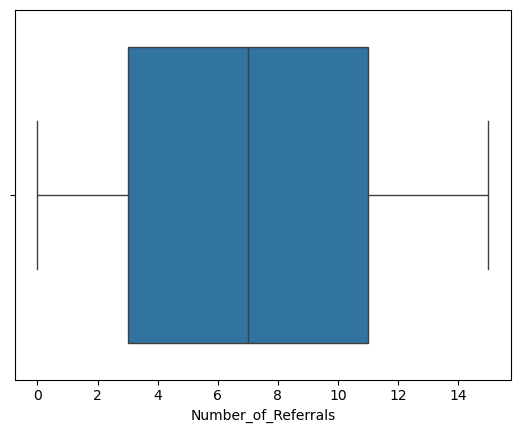

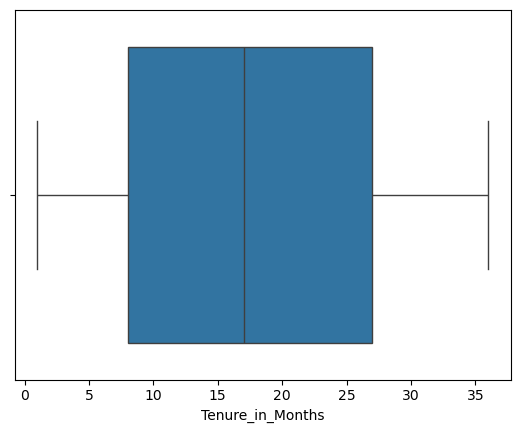

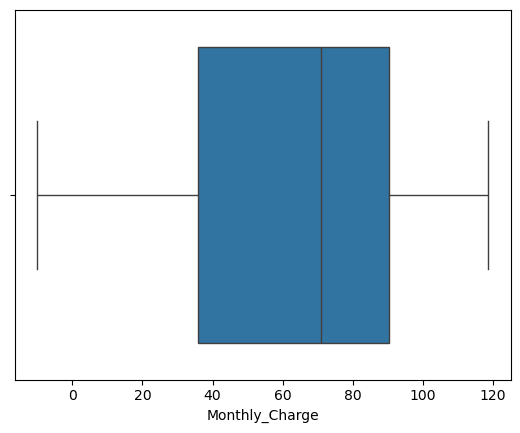

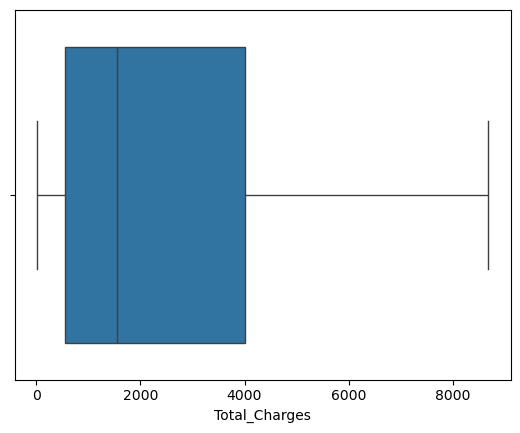

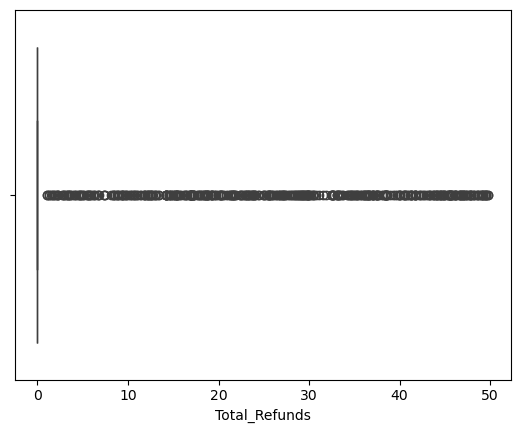

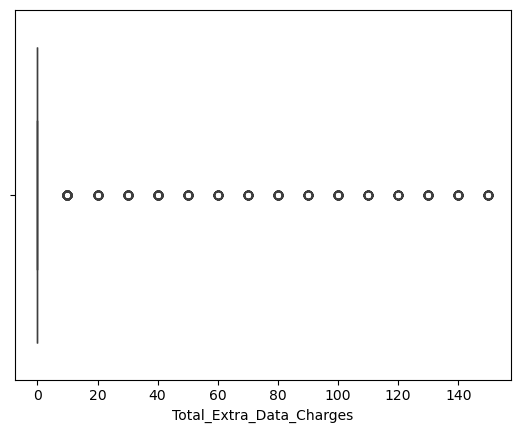

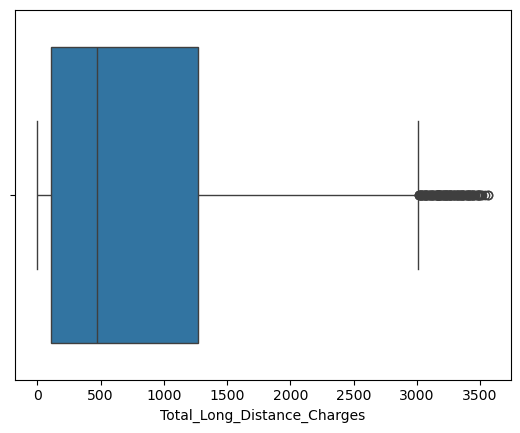

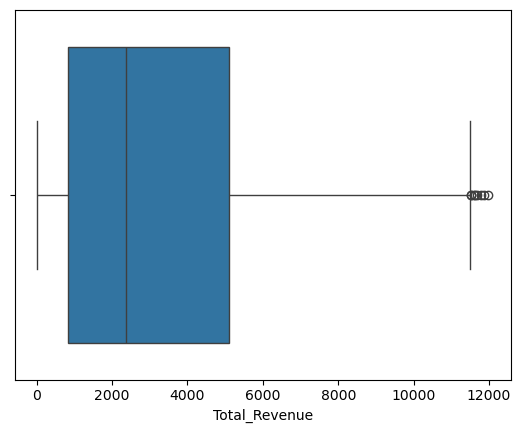

In [17]:
for col in num_df.columns:
    sns.boxplot(data=df,x=col)
    plt.show()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
2,11167-WES,Female,43,Yes,West Bengal,3,28,Deal 1,Yes,Yes,Yes,Fiber Optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Two Year,Yes,Bank Withdrawal,116.050003,8297.500000,42.570000,110,1872.979980,10237.910156,Stayed,Other,Other
91,12345-TEL,Female,71,Yes,Telangana,9,34,NaN,Yes,Yes,Yes,Cable,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.250000,1233.650024,48.090000,0,412.100006,1597.660034,Churned,Competitor,Competitor had better devices
97,12390-KAR,Male,24,Yes,Karnataka,9,12,NaN,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,No,No,No,Yes,Two Year,Yes,Credit Card,66.500000,4811.600098,45.610001,0,438.480011,5204.470215,Stayed,Other,Other
137,12853-HAR,Male,37,No,Haryana,11,18,Deal 2,Yes,No,Yes,Fiber Optic,No,Yes,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,80.000000,3168.750000,41.740002,0,1568.800049,4695.810059,Stayed,Other,Other
227,14087-UTT,Female,77,No,Uttar Pradesh,2,17,NaN,Yes,Yes,Yes,Fiber Optic,No,Yes,No,No,Yes,No,No,Yes,One Year,No,Credit Card,89.000000,1288.300049,45.689999,0,25.049999,1267.660034,Stayed,Other,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5611,94700-UTT,Female,26,No,Uttar Pradesh,8,21,NaN,Yes,Yes,Yes,DSL,Yes,Yes,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,67.449997,4508.649902,41.669998,0,1531.199951,5998.180176,Stayed,Other,Other
5640,95019-TEL,Male,40,No,Telangana,12,9,Deal 4,No,No,Yes,Cable,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,25.150000,331.850006,48.590000,0,0.000000,283.260010,Stayed,Other,Other
5826,97405-KER,Female,68,No,Kerala,8,31,Deal 4,Yes,No,No,NaN,No,No,No,No,No,No,No,No,One Year,No,Credit Card,20.049999,337.899994,43.680000,0,65.279999,359.500000,Stayed,Other,Other
5951,99166-BIH,Female,66,No,Bihar,9,27,NaN,Yes,Yes,Yes,Fiber Optic,Yes,No,No,No,No,No,No,Yes,Two Year,Yes,Bank Withdrawal,80.949997,4859.100098,49.529999,0,1093.800049,5903.370117,Stayed,Other,Other


In [25]:
# data Preprocessing 

In [35]:
df.Value_Deal.fillna(df.Value_Deal.mode()[0],inplace=True)

In [38]:
df.Internet_Type.fillna(df.Internet_Type.isna().mode()[0],inplace=True)

In [39]:
t_df = df.drop(columns=['Customer_ID','Churn_Category', 'Churn_Reason'])

In [52]:
train_col = cat_df.columns.drop('Customer_Status').union(num_df.columns)

In [ ]:
# one hot encoding 

In [56]:
encod_df = pd.get_dummies(df[train_col],dtype=int)

In [58]:
encod_df.shape

(6007, 74)

In [60]:
df.Customer_Status.value_counts()

Customer_Status
Stayed     4275
Churned    1732
Name: count, dtype: int64

In [61]:
churned_label = {'Stayed':0,'Churned':1}
y_label = df['Customer_Status'].map(churned_label)

In [62]:
# train test split 

In [63]:
Xtrain , Xtest , ytrain , ytest = train_test_split(encod_df,y_label,test_size=0.2,random_state=42,stratify=y_label)

In [66]:
Xtrain.shape , ytrain.shape

((4805, 74), (4805,))

In [68]:
Xtest.shape, ytest.shape

((1202, 74), (1202,))

In [138]:
rf = RandomForestClassifier(random_state=42,min_samples_split=15,max_depth=10,min_samples_leaf=20,oob_score=True)

In [139]:
model = rf.fit(Xtrain,ytrain)

In [140]:
# predict 
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

In [141]:
score = cross_val_score(rf,cv=4,scoring='accuracy',X=Xtrain,y=ytrain)
print(score)
print(score.mean())

[0.84193012 0.85678601 0.8459617  0.86344713]
0.8520312385269624


In [144]:
model.oob_score_

0.8484911550468263

In [145]:
# train Accuracy 
print(confusion_matrix(ytrain,pred_train))

[[3251  169]
 [ 460  925]]


In [146]:
print(classification_report(ytrain,pred_train))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      3420
           1       0.85      0.67      0.75      1385

    accuracy                           0.87      4805
   macro avg       0.86      0.81      0.83      4805
weighted avg       0.87      0.87      0.86      4805



In [147]:
# test accuracy 

In [148]:
print(confusion_matrix(ytest,pred_test))

[[814  41]
 [142 205]]


In [149]:
print(classification_report(ytest,pred_test))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       855
           1       0.83      0.59      0.69       347

    accuracy                           0.85      1202
   macro avg       0.84      0.77      0.80      1202
weighted avg       0.85      0.85      0.84      1202



In [154]:
# predict on new data test data 

In [160]:
test_df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11751-TAM,Female,18,No,Tamil Nadu,5,7,Deal 5,No,No,Yes,DSL,No,No,No,No,No,No,No,Yes,Month-to-Month,No,Mailed Check,24.299999,38.450001,0.0,0,0.000000,38.450001,Joined,Other,Other
1,12056-WES,Male,27,No,West Bengal,2,20,NaN,Yes,No,Yes,Fiber Optic,No,Yes,Yes,No,No,Yes,Yes,Yes,Month-to-Month,No,Bank Withdrawal,90.400002,268.450012,0.0,0,94.440002,362.890015,Joined,Other,Other
2,12136-RAJ,Female,25,Yes,Rajasthan,2,35,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Month-to-Month,No,Bank Withdrawal,19.900000,19.900000,0.0,0,11.830000,31.730000,Joined,Other,Other
3,12257-ASS,Female,39,No,Assam,9,1,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Month-to-Month,Yes,Credit Card,19.549999,19.549999,0.0,0,10.200000,29.750000,Joined,Other,Other
4,12340-DEL,Female,51,Yes,Delhi,0,10,NaN,Yes,No,Yes,Cable,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Credit Card,62.799999,62.799999,0.0,0,42.189999,104.989998,Joined,Other,Other


In [188]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  411 non-null    object 
 1   Gender                       411 non-null    object 
 2   Age                          411 non-null    int64  
 3   Married                      411 non-null    object 
 4   State                        411 non-null    object 
 5   Number_of_Referrals          411 non-null    int64  
 6   Tenure_in_Months             411 non-null    int64  
 7   Value_Deal                   411 non-null    object 
 8   Phone_Service                411 non-null    object 
 9   Multiple_Lines               411 non-null    object 
 10  Internet_Service             411 non-null    object 
 11  Internet_Type                411 non-null    object 
 12  Online_Security              411 non-null    object 
 13  Online_Backup       

In [161]:
test_df.isna().sum()

Customer_ID                      0
Gender                           0
Age                              0
Married                          0
State                            0
Number_of_Referrals              0
Tenure_in_Months                 0
Value_Deal                     251
Phone_Service                    0
Multiple_Lines                   0
Internet_Service                 0
Internet_Type                  167
Online_Security                  0
Online_Backup                    0
Device_Protection_Plan           0
Premium_Support                  0
Streaming_TV                     0
Streaming_Movies                 0
Streaming_Music                  0
Unlimited_Data                   0
Contract                         0
Paperless_Billing                0
Payment_Method                   0
Monthly_Charge                   0
Total_Charges                    0
Total_Refunds                    0
Total_Extra_Data_Charges         0
Total_Long_Distance_Charges      0
Total_Revenue       

In [162]:
test_df.Value_Deal.fillna(df.Value_Deal.mode()[0],inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_24904\2237767435.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df.Value_Deal.fillna(df.Value_Deal.mode()[0],inplace=True)


In [163]:
test_df.Internet_Type.fillna(df.Internet_Type.mode()[0],inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_24904\2720382064.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df.Internet_Type.fillna(df.Internet_Type.mode()[0],inplace=True)


In [172]:
train_col[train_col.isin(test_df.columns)]

Index(['Age', 'Contract', 'Device_Protection_Plan', 'Gender',
       'Internet_Service', 'Internet_Type', 'Married', 'Monthly_Charge',
       'Multiple_Lines', 'Number_of_Referrals', 'Online_Backup',
       'Online_Security', 'Paperless_Billing', 'Payment_Method',
       'Phone_Service', 'Premium_Support', 'State', 'Streaming_Movies',
       'Streaming_Music', 'Streaming_TV', 'Tenure_in_Months', 'Total_Charges',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Refunds', 'Total_Revenue', 'Unlimited_Data', 'Value_Deal'],
      dtype='object')

In [169]:
test_df.columns 

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'State',
       'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')

In [164]:
encod_test_df = pd.get_dummies(test_df[train_col],dtype=int)

In [165]:
encod_test_df.shape

(411, 70)

In [167]:
enod_df.shape

(6007, 74)

In [177]:
encod_df.columns.difference(encod_test_df.columns)

Index(['Internet_Type_False', 'Value_Deal_Deal 1', 'Value_Deal_Deal 3',
       'Value_Deal_Deal 4'],
      dtype='object')

In [178]:
tt = encod_test_df.copy()

In [181]:
encod_test_df[['Internet_Type_False', 'Value_Deal_Deal 1', 'Value_Deal_Deal 3',
       'Value_Deal_Deal 4']] = 0

In [183]:
final_test = encod_test_df[Xtrain.columns]

In [185]:
pred_ttest = model.predict(final_test)

In [190]:
test_df['pred_churn_no'] = pred_ttest

In [191]:
test_df['pred_churn'] = np.where(pred_ttest==1,'Churned','Stayed')

In [192]:
test_data = test_df[test_df['pred_churn_no']==1]

In [193]:
test_data.to_csv('pred_churn_customer_info.csv',index=False)